In [29]:
from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from kafkanator.dataviz import reliability_diagram_plot
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.metrics import brier_score_loss

In [30]:
import pandas as pd
import numpy as np

<h3> 1. Adult Dataset Download : The cell just beneath contains the code to download the ADULT dataset directly from the UCIML repository, sometimes
it doesn't work, in that case download the dataset here ( https://archive.ics.uci.edu/dataset/2/adult ) and plug it in the cell number 4 </h3> 

In [31]:
from ucimlrepo import fetch_ucirepo 
# fetch dataset 
adult = fetch_ucirepo(id=2) 
# data (as pandas dataframes) 
data = adult.data.features 
y = adult.data.targets 
# Data cleaning
y['income'] = y['income'].apply(lambda x: x.replace('.',''))
data['sex'] = data['sex'].str.strip()
data['race'] = data['race'].str.strip()
data['marital-status'] = data['marital-status'].str.strip()
data['native-country'] = data['native-country'].str.strip()

/tmp/ipykernel_13649/1730836504.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['income'] = y['income'].apply(lambda x: x.replace('.',''))
/tmp/ipykernel_13649/1730836504.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['sex'] = data['sex'].str.strip()
/tmp/ipykernel_13649/1730836504.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyda

In [4]:
# EXECUTE THIS CELL ONLY IF THERE IS NO AVAILABLE UCMIL REPOSITORY
data = pd.read_csv ('./adult/adult.data',names=[ 'age','workclass','fnlwgt','education','education-num','marital-status','occupation','relationship','race','sex','capital-gain','capital-loss','hours-per-week','native-country','income'] ) 
y= pd.DataFrame(data=data['income'])

In [32]:
data['race'] = data['race'].apply(lambda x : 1 if x=='White' else 0 )
categorical_columns = ['workclass', 'education',  'occupation', 'relationship', 'race', 'sex','marital-status','native-country']

# Create an instance of LabelEncoder
label_encoder = LabelEncoder()

# Encode each categorical column and create new feature columns
for col in categorical_columns:
    encoded_col_name = f"{col}_encoded"
    data[encoded_col_name] = label_encoder.fit_transform(data[col])

/tmp/ipykernel_13649/2740594744.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['race'] = data['race'].apply(lambda x : 1 if x=='White' else 0 )


In [33]:
X = data[['age','workclass_encoded', 'education_encoded','education-num','marital-status_encoded','occupation_encoded',	'relationship_encoded','race_encoded','sex_encoded','capital-loss','capital-gain','hours-per-week','native-country_encoded']]
y["income"] = label_encoder.fit_transform(y['income'])

/tmp/ipykernel_13649/840463995.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y["income"] = label_encoder.fit_transform(y['income'])


In [34]:
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.3, random_state=42)

<h3> 2. Random Forest predictor without calibration . </h3>

In [35]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Step 4: Make predictions on the testing set
y_pred_probs = rf_classifier.predict_proba(X_test)
forest_predictions = [x[1] for x in y_pred_probs]

/home/jsaray/env_jupyterlab/lib/python3.11/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [36]:
X_test['Prediction'] = forest_predictions
X_test['Real'] = y_test

<h3> 3. Invoke reliability_diagram_plot in your test set, by sending the sensitive column, sensistive values, prediction and reality column. </h3>

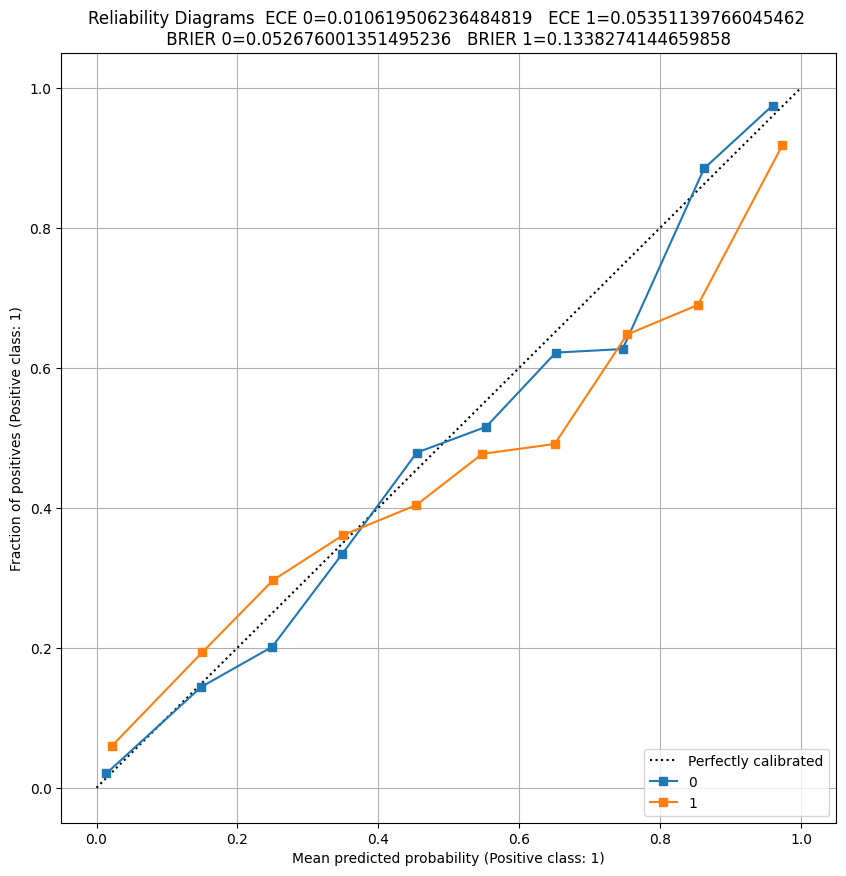

In [37]:
alldata = reliability_diagram_plot( X_test, 'sex_encoded', [0,1], 'Prediction' , 'Real' )

In [24]:
data[['sex','sex_encoded']]

,sex,sex_encoded
0,Male,1
1,Male,1
2,Male,1
3,Male,1
4,Female,0
...,...,...
48837,Female,0
48838,Male,1
48839,Male,1
48840,Male,1


<h3> Random Forest predictor with Calibration </h3>

In [38]:
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.3, random_state=42)
rf_classifier2 = RandomForestClassifier(n_estimators=100, random_state=42)
calibrated_rforest = CalibratedClassifierCV( rf_classifier2 , cv = 3, method='sigmoid' )
calibrated_rforest.fit(X_train, y_train)

/home/jsaray/env_jupyterlab/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:103: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/jsaray/env_jupyterlab/lib/python3.11/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/jsaray/env_jupyterlab/lib/python3.11/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/jsaray/env_jupyterlab/lib/python3.11/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was ex

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",RandomForestC...ndom_state=42)
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...x7f0a64e823d0>, <sk

In [39]:
y_log_probs_calibrated = calibrated_rforest.predict_proba(X_test)
forest_predictions_cal = [x[1] for x in y_log_probs_calibrated]

In [40]:
X_test['Prediction'] = forest_predictions_cal
X_test['Real'] = y_test

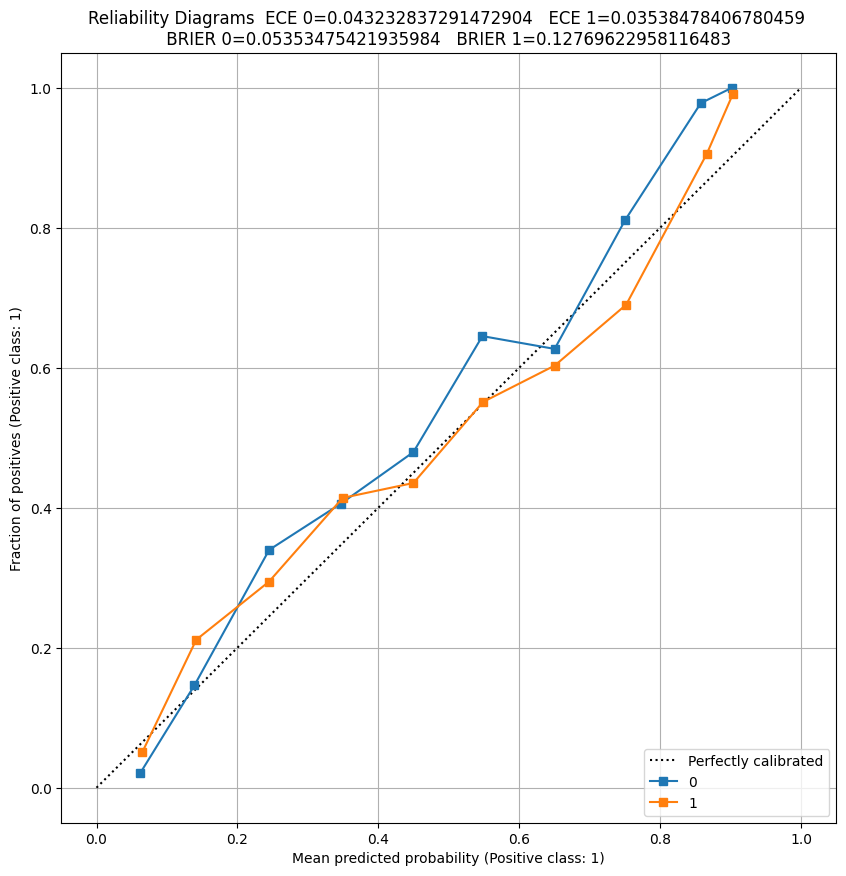

In [41]:
alldata = reliability_diagram_plot ( X_test, 'sex_encoded', [0,1], 'Prediction' , 'Real',bins=10 )

<h3> Logistic Regression without calibration </h3>

/home/jsaray/env_jupyterlab/lib/python3.11/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


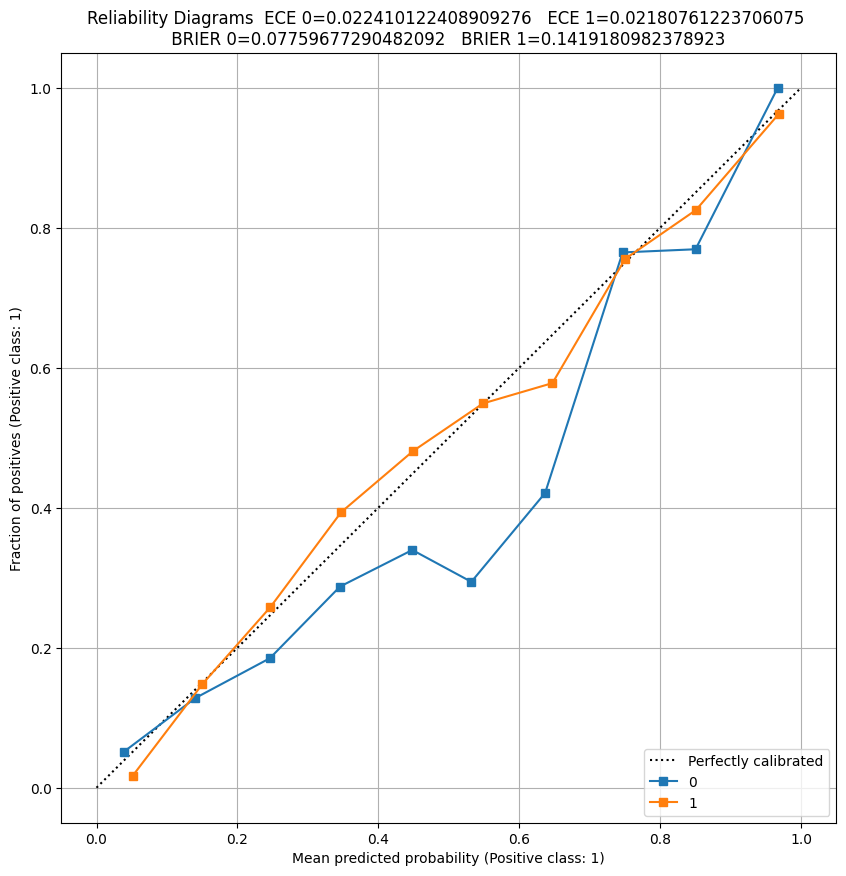

In [16]:
scaler = StandardScaler()
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.3, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the Logistic Regression Model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_log_probs = model.predict_proba(X_test_scaled)
logistic_predictions = [x[1] for x in y_log_probs]
X_test['Prediction'] = logistic_predictions
X_test['Real'] = y_test
alldata = reliability_diagram_plot ( X_test, 'sex_encoded', [0,1], 'Prediction' , 'Real' )

<h3>Logistic Regression with Calibration</h3>

In [17]:
scaler = StandardScaler()
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.3, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the Logistic Regression Model
logregmodel = LogisticRegression(max_iter=1000, random_state=42)
calibrated_log_reg = CalibratedClassifierCV( logregmodel , cv = 4 ,method='isotonic')
calibrated_log_reg.fit(X_train_scaled, y_train)

/home/jsaray/env_jupyterlab/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:103: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/jsaray/env_jupyterlab/lib/python3.11/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/jsaray/env_jupyterlab/lib/python3.11/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/jsaray/env_jupyterlab/lib/python3.11/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d arra

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LogisticRegre...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...x7ff068aabed0>, <s

In [18]:
y_cal_log_probs = calibrated_log_reg.predict_proba(X_test_scaled)
logistic_calibrated_predictions = [x[1] for x in y_cal_log_probs]
X_test['Prediction'] = logistic_calibrated_predictions
X_test['Real'] = y_test

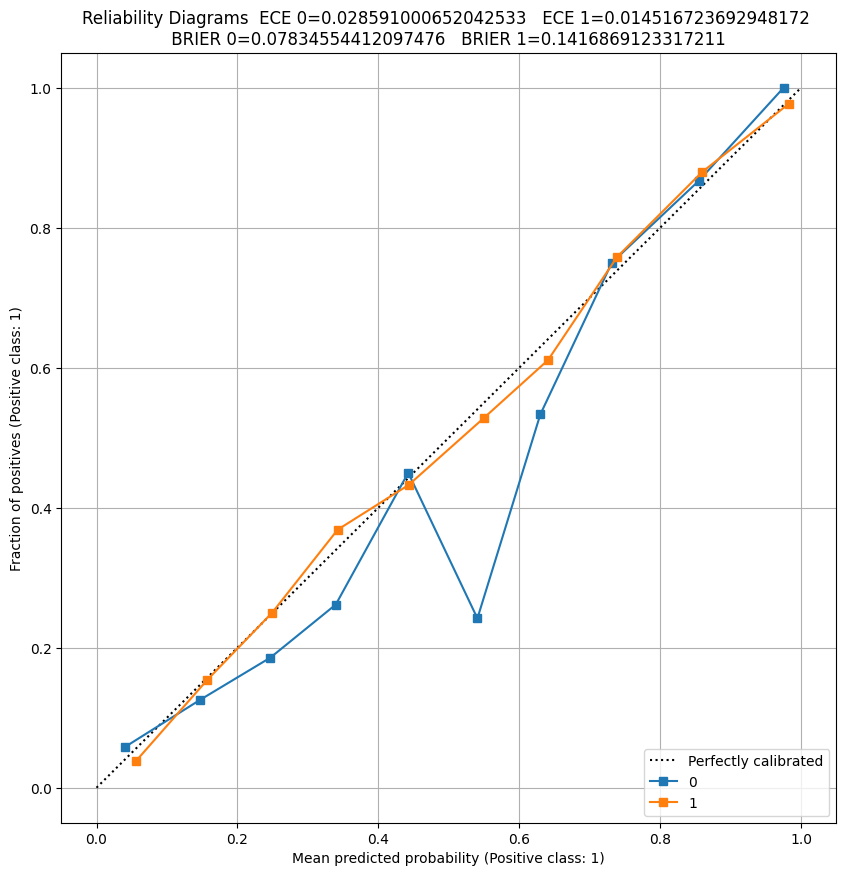

In [19]:
alldata = reliability_diagram_plot ( X_test, 'sex_encoded', [0,1], 'Prediction' , 'Real' )